# ***Social Media Usage Analysis Project***

# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Dataset

In [3]:

df = pd.read_csv('instagram_users_lifestyle.csv')
df.head()

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
0,1001,24,Female,Master,285,197,40,30.68,38,7,Former
1,1002,37,Male,Bachelor’s,359,59,87,26.45,45,6,Former
2,1003,32,Female,Master,84,123,29,78.24,67,6,No
3,1004,28,Male,Bachelor,196,222,155,59.72,63,2,No
4,1005,25,Female,Bachelor’s,22,175,230,54.95,63,10,Former


In [ ]:
df.tail()

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
495,1496,34,Male,High school,176,36,158,83.54,56,1,No
496,1497,41,Female,High school,24,132,83,42.06,44,10,No
497,1498,36,Female,Bachelor,105,100,201,90.17,37,5,Yes
498,1499,43,Male,Bachelor,194,96,14,95.52,38,2,No
499,1500,40,Male,Bachelor,309,145,109,31.90,42,7,No


## Basic Functions

In [ ]:
df.shape

(500, 11)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'education_level',
       'daily_active_minutes_instagram', 'reels_watched_per_day',
       'time_on_feed_per_day', 'User Activity Score', 'weekly_work_hours',
       'perceived_stress_score', 'smoking'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         500 non-null    int64  
 1   age                             500 non-null    int64  
 2   gender                          500 non-null    str    
 3   education_level                 500 non-null    str    
 4   daily_active_minutes_instagram  500 non-null    int64  
 5   reels_watched_per_day           500 non-null    int64  
 6   time_on_feed_per_day            500 non-null    int64  
 7   User Activity Score             500 non-null    float64
 8   weekly_work_hours               500 non-null    int64  
 9   perceived_stress_score          500 non-null    int64  
 10  smoking                         500 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 43.1 KB


In [ ]:
df.dtypes

user_id                             int64
age                                 int64
gender                                str
education_level                       str
daily_active_minutes_instagram      int64
reels_watched_per_day               int64
time_on_feed_per_day                int64
User Activity Score               float64
weekly_work_hours                   int64
perceived_stress_score              int64
smoking                               str
dtype: object

In [ ]:
df.describe()

,user_id,age,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,30.928000,189.522000,125.956000,127.794000,59.638940,44.716000,5.406000
std,144.481833,8.147612,102.212486,70.090766,67.002105,22.999789,14.128077,2.899997
min,1001.000000,18.000000,20.000000,5.000000,11.000000,20.130000,20.000000,1.000000
25%,1125.750000,24.000000,98.750000,67.750000,69.000000,40.670000,32.000000,3.000000
50%,1250.500000,31.000000,194.000000,128.500000,131.000000,59.630000,45.000000,5.000000
75%,1375.250000,38.000000,280.250000,184.000000,182.250000,78.687500,56.250000,8.000000
max,1500.000000,44.000000,359.000000,249.000000,239.000000,99.640000,69.000000,10.000000


In [ ]:
df.sample(5)

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
184,1185,30,Male,Bachelor,52,75,60,74.09,50,10,No
480,1481,24,Male,Bachelor,58,138,207,69.65,32,7,No
304,1305,19,Female,Bachelor,142,140,174,58.56,20,1,No
67,1068,20,Female,High school,87,79,23,58.78,38,4,No
465,1466,39,Female,High school,180,58,84,47.40,50,2,Yes


## Data Cleaning

In [ ]:
df.isnull().sum()

user_id                           0
age                               0
gender                            0
education_level                   0
daily_active_minutes_instagram    0
reels_watched_per_day             0
time_on_feed_per_day              0
User Activity Score               0
weekly_work_hours                 0
perceived_stress_score            0
smoking                           0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [ ]:
df['education_level'].unique()

<StringArray>
['Master', 'Bachelor’s', 'Bachelor', 'High school', 'HighSchool']
Length: 5, dtype: str

In [ ]:
df['education_level'].value_counts()

education_level
Bachelor       271
High school    100
Master          88
Bachelor’s      21
HighSchool      20
Name: count, dtype: int64

In [ ]:
df['education_level'] = df['education_level'].replace('Bachelor’s','Bachelor')
df['education_level'] = df['education_level'].replace('HighSchool','High school')

In [ ]:
df['education_level'].value_counts()

education_level
Bachelor       292
High school    120
Master          88
Name: count, dtype: int64

In [ ]:
df['smoking'].unique()

<StringArray>
['Former', 'No', 'Yes']
Length: 3, dtype: str

In [ ]:
df['smoking'].value_counts()

smoking
No        374
Yes        71
Former     55
Name: count, dtype: int64

In [ ]:
df['smoking'] = df['smoking'].replace('Former','No')

In [ ]:
df['smoking'].value_counts()

smoking
No     429
Yes     71
Name: count, dtype: int64

In [ ]:
df['gender']=df['gender'].str.strip()

In [ ]:
df['education_level']=df['education_level'].str.strip()

In [ ]:
df['smoking']=df['smoking'].str.strip()

In [ ]:
df.reset_index(drop=True,inplace=True)

## Data Filtering

In [ ]:
df[df['age']>30]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
1,1002,37,Male,Bachelor,359,59,87,26.45,45,6,No
2,1003,32,Female,Master,84,123,29,78.24,67,6,No
5,1006,38,Male,Bachelor,161,206,69,78.36,51,6,No
7,1008,43,Male,Bachelor,343,118,143,32.71,55,3,No
8,1009,36,Female,Bachelor,165,214,169,68.82,57,2,No
...,...,...,...,...,...,...,...,...,...,...,...
495,1496,34,Male,High school,176,36,158,83.54,56,1,No
496,1497,41,Female,High school,24,132,83,42.06,44,10,No
497,1498,36,Female,Bachelor,105,100,201,90.17,37,5,Yes
498,1499,43,Male,Bachelor,194,96,14,95.52,38,2,No


In [ ]:
df[df['gender']=='Male']

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
1,1002,37,Male,Bachelor,359,59,87,26.45,45,6,No
3,1004,28,Male,Bachelor,196,222,155,59.72,63,2,No
5,1006,38,Male,Bachelor,161,206,69,78.36,51,6,No
6,1007,24,Male,High school,177,162,200,81.24,25,4,No
7,1008,43,Male,Bachelor,343,118,143,32.71,55,3,No
...,...,...,...,...,...,...,...,...,...,...,...
493,1494,27,Male,High school,148,192,221,83.24,31,5,No
494,1495,36,Male,High school,283,16,58,29.99,30,5,No
495,1496,34,Male,High school,176,36,158,83.54,56,1,No
498,1499,43,Male,Bachelor,194,96,14,95.52,38,2,No


In [ ]:
df[df['gender']=='Female']

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
0,1001,24,Female,Master,285,197,40,30.68,38,7,No
2,1003,32,Female,Master,84,123,29,78.24,67,6,No
4,1005,25,Female,Bachelor,22,175,230,54.95,63,10,No
8,1009,36,Female,Bachelor,165,214,169,68.82,57,2,No
11,1012,28,Female,High school,212,140,139,72.56,43,2,No
...,...,...,...,...,...,...,...,...,...,...,...
484,1485,37,Female,Master,313,230,156,58.04,47,1,Yes
485,1486,32,Female,Bachelor,359,140,179,63.44,63,7,No
489,1490,37,Female,High school,327,29,78,77.77,23,9,No
496,1497,41,Female,High school,24,132,83,42.06,44,10,No


In [ ]:
df[df['User Activity Score']>80]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
6,1007,24,Male,High school,177,162,200,81.24,25,4,No
10,1011,28,Male,Master,172,30,52,80.11,52,5,Yes
12,1013,41,Female,Bachelor,92,51,69,96.53,42,2,No
18,1019,39,Female,High school,217,93,171,92.50,33,1,No
21,1022,41,Female,Bachelor,321,37,139,80.75,47,4,No
...,...,...,...,...,...,...,...,...,...,...,...
491,1492,30,Male,Master,253,72,73,89.60,67,6,No
493,1494,27,Male,High school,148,192,221,83.24,31,5,No
495,1496,34,Male,High school,176,36,158,83.54,56,1,No
497,1498,36,Female,Bachelor,105,100,201,90.17,37,5,Yes


In [ ]:
df[df['daily_active_minutes_instagram']>200]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
0,1001,24,Female,Master,285,197,40,30.68,38,7,No
1,1002,37,Male,Bachelor,359,59,87,26.45,45,6,No
7,1008,43,Male,Bachelor,343,118,143,32.71,55,3,No
9,1010,40,Male,Bachelor,312,149,102,30.83,30,1,No
11,1012,28,Female,High school,212,140,139,72.56,43,2,No
...,...,...,...,...,...,...,...,...,...,...,...
489,1490,37,Female,High school,327,29,78,77.77,23,9,No
490,1491,33,Male,Bachelor,355,83,102,62.67,54,1,No
491,1492,30,Male,Master,253,72,73,89.60,67,6,No
494,1495,36,Male,High school,283,16,58,29.99,30,5,No


In [ ]:
df[df['weekly_work_hours']>40]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
1,1002,37,Male,Bachelor,359,59,87,26.45,45,6,No
2,1003,32,Female,Master,84,123,29,78.24,67,6,No
3,1004,28,Male,Bachelor,196,222,155,59.72,63,2,No
4,1005,25,Female,Bachelor,22,175,230,54.95,63,10,No
5,1006,38,Male,Bachelor,161,206,69,78.36,51,6,No
...,...,...,...,...,...,...,...,...,...,...,...
491,1492,30,Male,Master,253,72,73,89.60,67,6,No
492,1493,35,Male,High school,27,177,174,30.45,45,6,No
495,1496,34,Male,High school,176,36,158,83.54,56,1,No
496,1497,41,Female,High school,24,132,83,42.06,44,10,No


In [ ]:
df[df['perceived_stress_score']>=8]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
4,1005,25,Female,Bachelor,22,175,230,54.95,63,10,No
14,1015,21,Male,Bachelor,159,117,220,24.56,46,8,No
15,1016,25,Female,Bachelor,206,80,40,42.57,30,10,No
16,1017,41,Female,Master,312,223,14,40.94,69,8,No
22,1023,29,Male,High school,30,5,135,55.98,66,8,Yes
...,...,...,...,...,...,...,...,...,...,...,...
476,1477,38,Male,Bachelor,236,184,116,99.51,52,10,No
477,1478,29,Male,Bachelor,325,135,122,90.43,36,9,No
482,1483,23,Female,Bachelor,203,145,118,51.61,30,8,No
489,1490,37,Female,High school,327,29,78,77.77,23,9,No


In [ ]:
df[df['User Activity Score']=='Bachelor']

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking


In [ ]:
df[(df['age']>25)&(df['User Activity Score']>60)]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
2,1003,32,Female,Master,84,123,29,78.24,67,6,No
5,1006,38,Male,Bachelor,161,206,69,78.36,51,6,No
8,1009,36,Female,Bachelor,165,214,169,68.82,57,2,No
10,1011,28,Male,Master,172,30,52,80.11,52,5,Yes
11,1012,28,Female,High school,212,140,139,72.56,43,2,No
...,...,...,...,...,...,...,...,...,...,...,...
491,1492,30,Male,Master,253,72,73,89.60,67,6,No
493,1494,27,Male,High school,148,192,221,83.24,31,5,No
495,1496,34,Male,High school,176,36,158,83.54,56,1,No
497,1498,36,Female,Bachelor,105,100,201,90.17,37,5,Yes


In [ ]:
df[(df['gender']=='Female')&(df['perceived_stress_score']>7)]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
4,1005,25,Female,Bachelor,22,175,230,54.95,63,10,No
15,1016,25,Female,Bachelor,206,80,40,42.57,30,10,No
16,1017,41,Female,Master,312,223,14,40.94,69,8,No
28,1029,43,Female,Bachelor,71,52,210,92.51,67,10,No
31,1032,42,Female,Bachelor,91,94,146,52.89,64,10,Yes
...,...,...,...,...,...,...,...,...,...,...,...
466,1467,34,Female,Bachelor,198,37,112,41.62,49,10,No
469,1470,23,Female,Bachelor,295,18,153,47.78,25,8,No
482,1483,23,Female,Bachelor,203,145,118,51.61,30,8,No
489,1490,37,Female,High school,327,29,78,77.77,23,9,No


In [ ]:
df[(df['daily_active_minutes_instagram']>150)&(df['reels_watched_per_day']>100)]

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
0,1001,24,Female,Master,285,197,40,30.68,38,7,No
3,1004,28,Male,Bachelor,196,222,155,59.72,63,2,No
5,1006,38,Male,Bachelor,161,206,69,78.36,51,6,No
6,1007,24,Male,High school,177,162,200,81.24,25,4,No
7,1008,43,Male,Bachelor,343,118,143,32.71,55,3,No
...,...,...,...,...,...,...,...,...,...,...,...
484,1485,37,Female,Master,313,230,156,58.04,47,1,Yes
485,1486,32,Female,Bachelor,359,140,179,63.44,63,7,No
486,1487,20,Male,Bachelor,170,153,44,38.22,25,3,No
488,1489,25,Male,High school,320,200,163,92.76,35,2,No


## Grouping

In [ ]:
df.groupby('gender')['User Activity Score'].mean()

gender
Female    59.032137
Male      60.172744
Name: User Activity Score, dtype: float64

In [ ]:
df.groupby('education_level')['daily_active_minutes_instagram'].mean()

education_level
Bachelor       191.335616
High school    180.941667
Master         195.204545
Name: daily_active_minutes_instagram, dtype: float64

In [ ]:
df.groupby('smoking')['perceived_stress_score'].mean()

smoking
No     5.372960
Yes    5.605634
Name: perceived_stress_score, dtype: float64

In [ ]:
df.groupby('gender')['weekly_work_hours'].sum()

gender
Female    10507
Male      11851
Name: weekly_work_hours, dtype: int64

In [ ]:
df.groupby('education_level')['age'].mean()

education_level
Bachelor       30.815068
High school    31.025000
Master         31.170455
Name: age, dtype: float64

In [ ]:
df.groupby('gender')['reels_watched_per_day'].mean()

gender
Female    132.128205
Male      120.526316
Name: reels_watched_per_day, dtype: float64

In [ ]:
df.groupby('smoking')['User Activity Score'].max()

smoking
No     99.64
Yes    98.68
Name: User Activity Score, dtype: float64

In [ ]:
df.groupby(['gender','education_level'])['User Activity Score'].mean()

gender  education_level
Female  Bachelor           60.400432
        High school        56.586545
        Master             57.640000
Male    Bachelor           57.876928
        High school        64.008462
        Master             62.296458
Name: User Activity Score, dtype: float64

## Sorting

In [ ]:
df.sort_values('age')

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
400,1401,18,Female,Bachelor,312,229,230,45.51,24,1,No
359,1360,18,Female,Bachelor,351,59,23,48.38,51,2,No
26,1027,18,Male,Bachelor,172,146,65,22.69,64,9,No
378,1379,18,Male,Bachelor,281,108,147,43.60,44,3,Yes
347,1348,18,Female,Master,101,40,178,24.76,47,7,No
...,...,...,...,...,...,...,...,...,...,...,...
375,1376,44,Female,Master,247,122,134,31.37,27,10,No
310,1311,44,Male,Master,223,200,127,20.44,68,3,No
274,1275,44,Female,High school,107,89,145,45.36,55,7,No
34,1035,44,Male,Bachelor,329,198,82,21.75,68,10,No


In [ ]:
df.sort_values('age',ascending=False)

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
274,1275,44,Female,High school,107,89,145,45.36,55,7,No
269,1270,44,Male,High school,308,157,27,86.34,60,9,No
34,1035,44,Male,Bachelor,329,198,82,21.75,68,10,No
310,1311,44,Male,Master,223,200,127,20.44,68,3,No
362,1363,44,Female,High school,178,149,190,74.29,26,6,No
...,...,...,...,...,...,...,...,...,...,...,...
122,1123,18,Female,Master,210,47,114,88.57,57,3,No
112,1113,18,Male,High school,187,157,236,66.21,64,8,No
107,1108,18,Male,High school,308,202,205,97.16,33,7,Yes
446,1447,18,Male,Master,63,11,122,68.24,30,1,No


In [ ]:
df.sort_values('User Activity Score',ascending=False)

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
259,1260,22,Male,Bachelor,296,167,129,99.64,60,3,No
476,1477,38,Male,Bachelor,236,184,116,99.51,52,10,No
330,1331,23,Female,Master,106,90,12,99.43,57,10,No
424,1425,34,Male,Bachelor,137,147,161,99.04,23,7,No
94,1095,38,Female,Bachelor,100,204,182,98.80,42,5,No
...,...,...,...,...,...,...,...,...,...,...,...
376,1377,19,Male,Bachelor,85,9,141,20.94,52,5,No
365,1366,40,Female,Bachelor,23,140,84,20.81,35,1,No
311,1312,40,Female,Bachelor,283,17,28,20.61,29,6,Yes
310,1311,44,Male,Master,223,200,127,20.44,68,3,No


In [ ]:
df.sort_values('daily_active_minutes_instagram',ascending=False)

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
1,1002,37,Male,Bachelor,359,59,87,26.45,45,6,No
485,1486,32,Female,Bachelor,359,140,179,63.44,63,7,No
247,1248,29,Male,High school,359,53,133,23.85,40,6,No
56,1057,43,Female,Master,357,136,187,88.05,40,4,No
262,1263,23,Male,Bachelor,357,164,131,25.09,67,4,No
...,...,...,...,...,...,...,...,...,...,...,...
60,1061,19,Female,Bachelor,22,230,200,88.81,60,3,No
399,1400,20,Female,High school,21,40,13,54.48,28,6,No
287,1288,35,Male,Bachelor,21,50,22,50.76,64,1,No
435,1436,20,Female,Bachelor,20,86,185,51.04,66,2,No


In [ ]:
df.sort_values('weekly_work_hours')

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
77,1078,27,Female,Bachelor,351,203,239,61.00,20,4,No
81,1082,43,Male,High school,44,64,224,82.90,20,9,No
430,1431,33,Male,Master,276,16,126,60.44,20,8,No
89,1090,25,Male,High school,109,176,227,90.23,20,9,No
139,1140,22,Male,Bachelor,96,147,212,53.42,20,7,No
...,...,...,...,...,...,...,...,...,...,...,...
442,1443,42,Male,Bachelor,223,210,234,29.29,69,8,No
439,1440,30,Male,High school,140,220,192,56.68,69,6,No
47,1048,24,Male,Bachelor,66,81,110,65.23,69,8,No
481,1482,21,Female,Bachelor,242,29,90,36.10,69,6,No


In [ ]:
df.sort_values(['gender','age'])

,user_id,age,gender,education_level,daily_active_minutes_instagram,reels_watched_per_day,time_on_feed_per_day,User Activity Score,weekly_work_hours,perceived_stress_score,smoking
122,1123,18,Female,Master,210,47,114,88.57,57,3,No
305,1306,18,Female,High school,28,101,198,35.69,55,4,No
347,1348,18,Female,Master,101,40,178,24.76,47,7,No
359,1360,18,Female,Bachelor,351,59,23,48.38,51,2,No
400,1401,18,Female,Bachelor,312,229,230,45.51,24,1,No
...,...,...,...,...,...,...,...,...,...,...,...
217,1218,44,Male,High school,182,220,128,28.86,68,9,No
255,1256,44,Male,Bachelor,83,154,41,39.16,56,5,No
269,1270,44,Male,High school,308,157,27,86.34,60,9,No
310,1311,44,Male,Master,223,200,127,20.44,68,3,No


## Aggregations

In [ ]:
df['age'].min()

np.int64(18)

In [ ]:
df['age'].max()

np.int64(44)

In [ ]:
df['age'].mean()

np.float64(30.928)

In [ ]:
df['age'].median()

np.float64(31.0)

In [ ]:
df['age'].mode()

0    18
1    20
Name: age, dtype: int64

In [ ]:
df['age'].var()

np.float64(66.38358316633267)

In [ ]:
df['User Activity Score'].min()

np.float64(20.13)

### numpy

In [ ]:
np.mean(df['age'])

np.float64(30.928)

In [ ]:
np.max(df['User Activity Score'])

np.float64(99.64)

In [ ]:
np.min(df['User Activity Score'])

np.float64(20.13)

In [ ]:
np.median(df['age'])

np.float64(31.0)

In [ ]:
np.var(df['User Activity Score'])

np.float64(527.9322926764)

In [ ]:
np.std(df['User Activity Score'])

np.float64(22.976777247394814)

In [ ]:
df['User Activity Score'].max()

np.float64(99.64)

In [ ]:
df['User Activity Score'].mean()

np.float64(59.638940000000005)

In [ ]:
df['User Activity Score'].median()

np.float64(59.629999999999995)

In [ ]:
df['User Activity Score'].mode()

0     31.14
1     42.15
2     48.95
3     50.43
4     56.74
5     57.11
6     59.01
7     61.01
8     61.87
9     63.26
10    70.73
11    70.77
12    72.18
13    88.46
14    97.12
Name: user_engagement_score, dtype: float64

In [ ]:
df['User Activity Score'].var()

np.float64(528.9902732228458)

In [ ]:
df['daily_active_minutes_instagram'].mean()

np.float64(189.522)

In [ ]:
df['weekly_work_hours'].mean()

np.float64(44.716)

In [ ]:
df['perceived_stress_score'].mean()

np.float64(5.406)

## Visualization

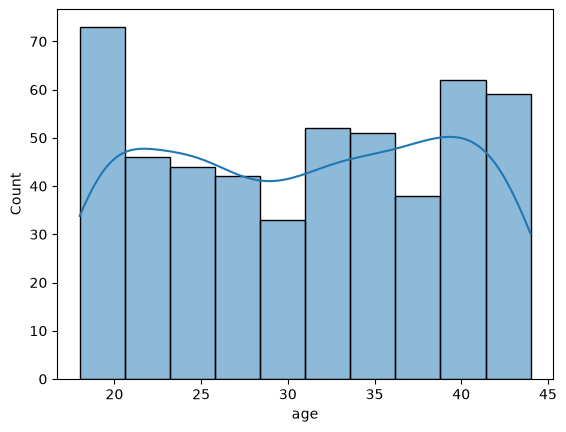

In [ ]:

sns.histplot(df['age'],kde=True)
plt.show()

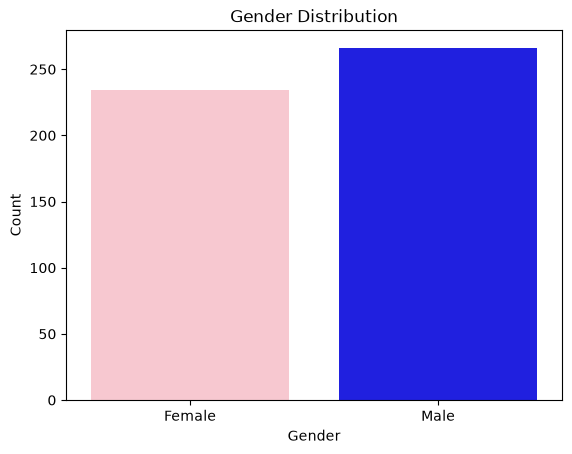

In [ ]:
sns.countplot(
    x='gender',
    data=df,
    hue='gender',
    palette={'Male':'blue', 'Female':'pink'}
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

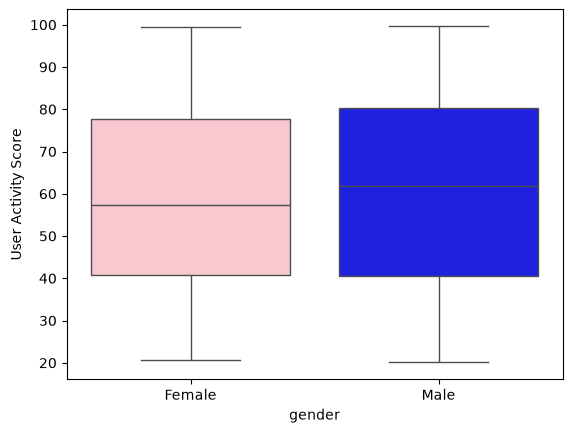

In [ ]:
sns.boxplot(x='gender',y='User Activity Score',data=df,hue='gender',palette={'Male':'blue', 'Female':'pink'})
plt.show()

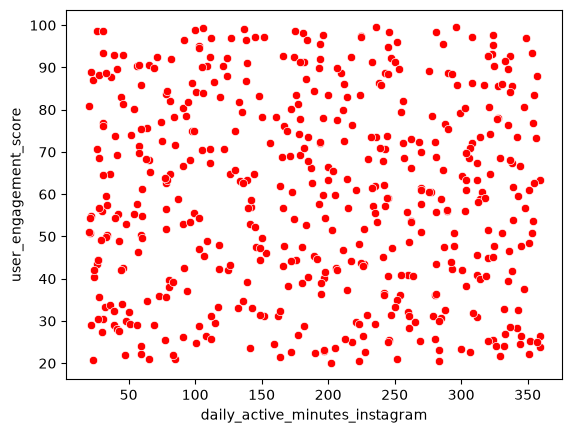

In [ ]:
sns.scatterplot(
    x='daily_active_minutes_instagram',
    y='User Activity Score',
    data=df,
    color='red'
)

plt.show()

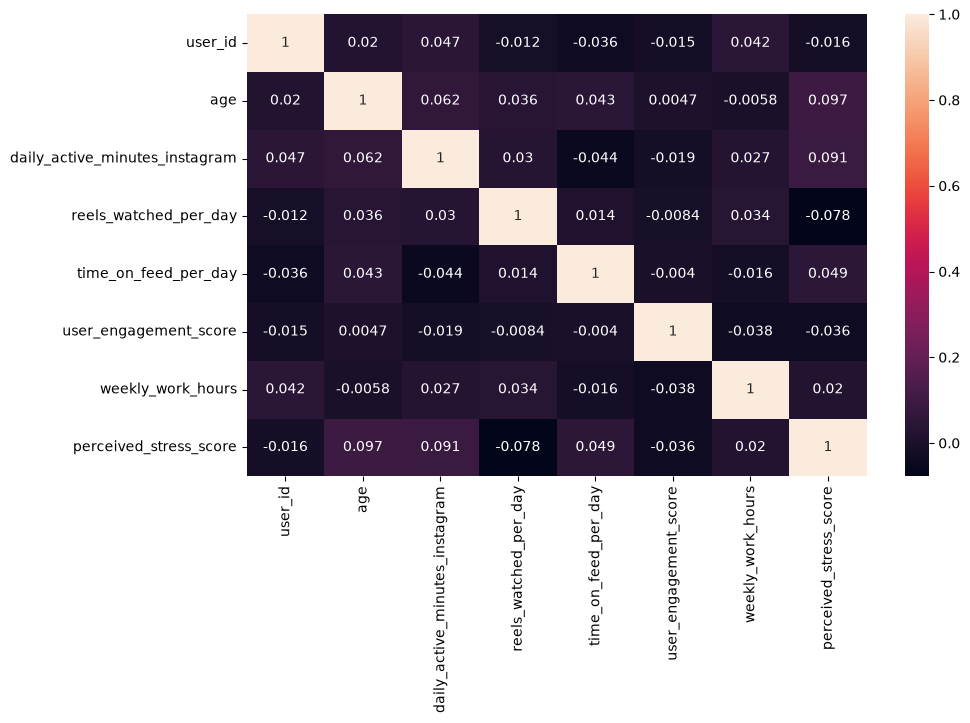

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes('number').corr(),annot=True)
plt.show()